# Meeting Notes

**Pre-Meeting Notes/Topics to Discuss:**
- I probably want to get ~10,000 images
    - Currently bugfixing a system to get the road geometry from OpenStreetMap then query random coordinates along roads in Oakland for images from StreetView
        - Also consider getting it as a vector map and then selecting from the roads
    - I can realistically get most of the raw data downloaded by this weekend but I'm limited by the rate limit (need to download ~7 GB of images)
- How am I going to label 10k images in a reasonable amount of time?
    - Still not sure about this at all
    - Some commercial options for labelling exist
    - Probably want to use semisupervised or active learning because I'm worried that this might be too much data to realistically label
    1. I can cluster the data based on Sonja's dataset (perhaps -- look into it??)
- I also know how I'm going to build the model: Fine tune on Meta's Segment Anything Model (SAM) with [SAM_LoRA](https://github.com/MathieuNlp/Sam_LoRA)
    - Mostly just need the data
    - Changed my mind about the model intricaces like sign detection and valid parking spots being built into the model, this can just be built into the dataset
- The transformation I need to convert the output labels into overhead spots is called a homographic transform.
    - I can develop the model for this while I work on getting the dataset
    - Resources for this exist [online](https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html)
- Project presentation
    - Need to clarify how to frame this project!!!!

**To Do:**
- Work on getting the papers
- Work on setting up GitHub

# Research

In [1]:
%load_ext dotenv
%dotenv

### Downloading the Data

In [2]:
import os, csv, random, time

In [3]:
API_KEY=os.getenv('API_KEY')
IMG_PITCH=0
OUTPUT_DIR='oakland_images'

In [4]:
import requests, json
from io import BytesIO
from PIL import Image

To begin, we'll need a function for directly querying the Google StreetView API. Each of the parameters are important, and are described on the StreetView documentation [1](https://developers.google.com/maps/documentation/streetview/request-streetview).

In [5]:
def streetview_query_url(lat: float, lon: float, direction: int, size: int, pitch: int):
    """
    Queries Google StreetView with the given parameters,
    i.e. a direct interface for the API
    """
    url = 'https://maps.googleapis.com/maps/api/streetview?' + \
    ('&location=%.7f,%.7f' % (lat,lon)) + \
    ('&size=%dx%d' % (size,size)) + \
    ('&heading=%d' % direction) + \
    ('&pitch=%d' % IMG_PITCH) + \
    ('&key=%s' % API_KEY)
    
    return url

And then, some simplified wrappers to actually work with this:

In [6]:
from shapely import Point

def get_streetview_image(lat: float, lon: float, direction: int = 0, size : int = 640, pitch : int = 0):
    """
    Simplified wrapper around the query method.
    """
    url = streetview_query_url(lat, lon, direction, size, pitch)
    r = requests.get(url)
    r.raise_for_status()
    return Image.open(BytesIO(r.content))

def query_streetview_point(p: Point, direction: int = 0, pitch : int = 0):
    return get_streetview_image(lat=p.y, lon=p.x, 
                                direction = direction, 
                                pitch = pitch)

In [7]:
def has_imagery(lat: float, lon: float) -> bool:
    """
    Checks if imagery exists at a coordinate.
    """
    meta_url = (
        "https://maps.googleapis.com/maps/api/streetview/metadata"
        f"?location={lat},{lon}&key={API_KEY}"
    )
    meta = requests.get(meta_url).json()
    return meta.get("status") == "OK"

We can verify the code just using any set of coordinates, so here is a picture of the street by my apartment:

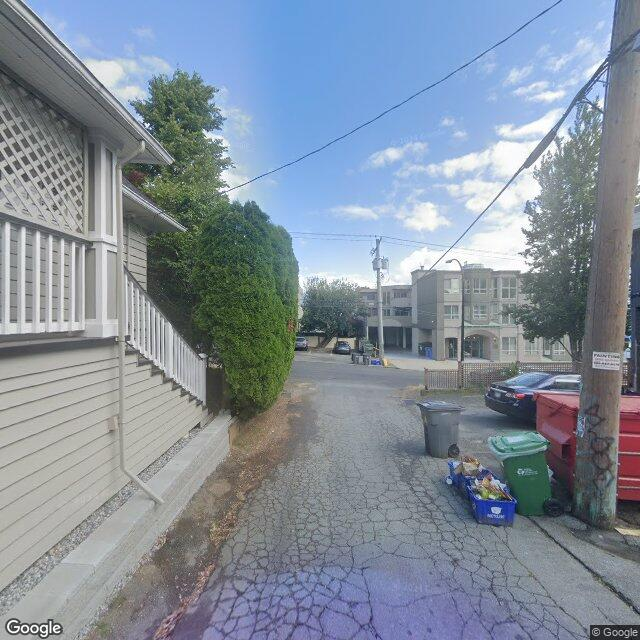

In [8]:
get_streetview_image(49.2571476, -123.1857815)

(Before the next cell, we need to download the road geometry of Oakland. A simple database to do this is located online [2](https://services.arcgis.com/9tC74aDHuml0x5Yz/arcgis/rest/services/OaklandStreet/FeatureServer/0), but for some reason, they make it REALLY hard to download from ArcGIS without using their REST API.)

In [9]:
import geopandas, pandas

DOWNLOAD_ROAD_GEOMETRY=False
ROAD_MAP_URL = "https://services.arcgis.com/9tC74aDHuml0x5Yz/" + \
    "arcgis/rest/services/OaklandStreet/FeatureServer/0/query"
ROAD_GEOMETRY_GEOJSON_FILE="OaklandStreet.geojson"

if DOWNLOAD_ROAD_GEOMETRY:
    print('Downloading Road Geometry...')
    
    # Parameters for the request
    resp = requests.get(ROAD_MAP_URL, params={
        "where": "1=1",
        "outFields": "*",
        "outSR": "4326",
        "returnGeometry": "true",
        "f": "geojson"
    })
    resp.raise_for_status()

    with open(ROAD_GEOMETRY_GEOJSON_FILE, "w", encoding="utf-8") as f:
        json.dump(resp.json(), f)
        
    print('Downloaded!')

(We can just verify the above map using QGIS or some other service.)

We want to randomly sample Google StreetView within the bounding box, but only along road geometry. We can do this using OpenStreetMap, by first definining the bounding boxes we want to search, then converting them into sets of valid geometry that we can query. We can do this by loading up non-interstate and freeway/expressway roads (principal arterial, minor arterial, major collector, and local roads) from the Oakland Streets Map database [1](https://services.arcgis.com/9tC74aDHuml0x5Yz/arcgis/rest/services/OaklandStreet/FeatureServer/0) and then random sample them for points within this geometry:

In [10]:
from shapely.geometry import LineString

ROAD_GEOM = geopandas.read_file(ROAD_GEOMETRY_GEOJSON_FILE)

def random_sample_road_point():
    """
    Obtains a random point along the 
    roads of Oakland for analysis
    """
    
    # Pick a random road feature
    road = ROAD_GEOM.sample(1).geometry.iloc[0]
    
    # Handle MultiLineStrings by picking one part
    if road.geom_type == "MultiLineString":
        road = random.choice(list(road.geoms))
    
    # Pick a random location along the line
    random_distance = random.uniform(0, road.length)
    point = road.interpolate(random_distance)
    
    return point

Now, we can just test that this actually works by directly trying to use it:

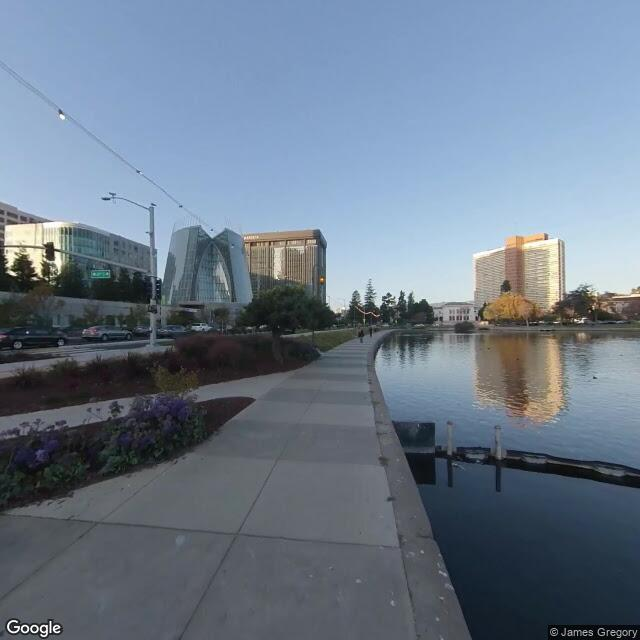

In [11]:
query_streetview_point(random_sample_road_point())

When we download an image, we want to keep the geotag information. The easiest way to do this is to store the geographic coordinates (alongside the other geometric query parameters) directly in the metadata of the image. First, we'll need a function to convert the latitude and longitude information into a degrees-minutes-seconds (DMS) tuple that can actually be stored in the file.

In [12]:
def deg_to_dms_rational(deg):
    """
    Convert decimal degrees to EXIF-compatible 
    DMS (degrees, minutes, seconds) rational tuples.
    """
    
    deg_abs = abs(deg)
    minutes, seconds = divmod(deg_abs * 3600, 60)
    degrees, minutes = divmod(minutes, 60)
    
    return [
        (int(degrees), 1),
        (int(minutes), 1),
        (int(seconds * 100), 100)
    ]

And then, we can finish the function for writing the image metadata:

In [13]:
import piexif, io

def write_image_metadata(image_data: Image, point: Point, direction):
    """
    Saves the GPS coordinates and the direction angle to the metadata of the image
    """
    # Extract latitude and longitude
    lat, lon = point.y, point.x

    # Load existing EXIF data (or initialize if missing)
    exif_bytes = image_data.info.get("exif", None)
    exif_dict = piexif.load(exif_bytes) if exif_bytes else {"0th": {}, "Exif": {}, "GPS": {}, "1st": {}}

    # Set GPS metadata
    exif_dict["GPS"][piexif.GPSIFD.GPSLatitudeRef] = "N" if lat >= 0 else "S"
    exif_dict["GPS"][piexif.GPSIFD.GPSLatitude] = deg_to_dms_rational(lat)
    exif_dict["GPS"][piexif.GPSIFD.GPSLongitudeRef] = "E" if lon >= 0 else "W"
    exif_dict["GPS"][piexif.GPSIFD.GPSLongitude] = deg_to_dms_rational(lon)

    # Add direction (bearing)
    exif_dict["GPS"][piexif.GPSIFD.GPSImgDirectionRef] = b"T"  # True North
    exif_dict["GPS"][piexif.GPSIFD.GPSImgDirection] = (int(direction * 100), 100)  # rational number

    # Dump updated EXIF data to bytes
    updated_exif = piexif.dump(exif_dict)

    # Write image to a BytesIO buffer with updated EXIF
    output_buffer = io.BytesIO()
    image_data.save(output_buffer, format=image_data.format, exif=updated_exif)
    
    return output_buffer.getvalue()

We can also test this function (just to be sure):

In [14]:
def test_write_image_metadata():
    img = Image.new("RGB", (100, 100), color="white")
    img.format = "JPEG"
    
    dummy_point = Point(37.7749, -122.4194) # Latitude, Longitude
    dummy_direction = 123.45
    
    new_bytes = write_image_metadata(img, dummy_point, dummy_direction)
    
    img_with_exif = Image.open(io.BytesIO(new_bytes))
    exif_data = piexif.load(img_with_exif.info["exif"])
    
    gps_ifd = exif_data["GPS"]
    saved_direction = gps_ifd[piexif.GPSIFD.GPSImgDirection]
    
    print("Latitude (DMS):", gps_ifd[piexif.GPSIFD.GPSLatitude])
    print("Longitude (DMS):", gps_ifd[piexif.GPSIFD.GPSLongitude])
    print("Direction:", saved_direction)
    
    # check correctness
    assert gps_ifd[piexif.GPSIFD.GPSLatitudeRef].decode('ascii') == "S"
    assert gps_ifd[piexif.GPSIFD.GPSLongitudeRef].decode('ascii') == "E"
    assert saved_direction == (int(dummy_direction * 100), 100)
    
    print("EXIF metadata successfully written and verified!")

test_write_image_metadata()

Latitude (DMS): ((122, 1), (25, 1), (983, 100))
Longitude (DMS): ((37, 1), (46, 1), (2964, 100))
Direction: (12345, 100)
EXIF metadata successfully written and verified!


We can also add this metadata to a master CSV file, and then produce the rest of our function to download all of the images (up to some number).

In [15]:
import shutil
import numpy as np

OUTPUT_DIRECTORY='data'
IMAGE_FILE_OUTPUT=f'{OUTPUT_DIRECTORY}/images'
METADATA_FILE_OUTPUT=f'{OUTPUT_DIRECTORY}/metadata.csv'

METADATA_HEADER = [ 'LABEL', 'LON', 'LAT', 'DIR' ]

def download_all_images(num_images):
    """
    Downloads all of the images, geotagging each one 
    with the geographic coordinates. 
    """
    
    # Delete all of the previous files stored within the data
    # directory if previous data exists
    if os.path.exists(OUTPUT_DIRECTORY):
        shutil.rmtree(OUTPUT_DIRECTORY)
    
    # Make the directories and files
    os.makedirs(OUTPUT_DIRECTORY)
    os.makedirs(IMAGE_FILE_OUTPUT)
    
    interval = max(num_images // 10, 1)
    metadata = []
    
    for count in range(1, num_images + 1):
        
        # get a random point and direction
        point = random_sample_road_point()
        direction = np.random.randint(0, 360)
        
        # then download the image
        image = query_streetview_point(point, direction = direction)
        image_label = f'{count}.png'
        image_path = f'{IMAGE_FILE_OUTPUT}/{image_label}'
        
        # append the location and direction onto the metadata
        image_tagged = write_image_metadata(image, point, direction)
        
        # then, we can save the image and save its data to the CSV
        with open(image_path, "wb") as f:
            f.write(image_tagged)
        metadata.append([image_label, point.x, point.y, direction])
        
        if count % interval == 0:
            print(f'{(count / num_images) * 100:.0f}% - {count}/{num_images}')
    
    # write the master metadata csv
    if len(metadata) > 0:
        with open(METADATA_FILE_OUTPUT, 'a', newline='') as csv_file:
            csv_writer = csv.writer(csv_file)
            csv_writer.writerow(METADATA_HEADER)
            csv_writer.writerows(metadata)

Now, we can download some data:

In [16]:
download_all_images(200)

10% - 20/200
20% - 40/200
30% - 60/200
40% - 80/200
50% - 100/200
60% - 120/200
70% - 140/200
80% - 160/200
90% - 180/200
100% - 200/200


And we can check it by printing out the contents of the image directory and the metadata file:

In [17]:
import pandas as pd

metadata = pd.read_csv(METADATA_FILE_OUTPUT)
print(metadata.head())

   LABEL         LON        LAT  DIR
0  1.png -122.266276  37.835293  323
1  2.png -122.220808  37.828659  126
2  3.png -122.206978  37.768614  119
3  4.png -122.183884  37.759531  357
4  5.png -122.177631  37.733812  171


And to check the success of this, we can plot a map of each of these points that we've downloaded:

In [18]:
import folium

map_center = (metadata['LAT'].mean(), metadata['LON'].mean())
m = folium.Map(location=map_center, zoom_start=12)

for _, row in metadata.iterrows():
    pos = [ row['LAT'], row['LON'] ]
    direction = row['DIR']
    label = row['LABEL']
    
    folium.Marker(
        location=pos,
        popup=f"Label: {label}\nDirection: {direction}°"
    ).add_to(m)
    
m

### Labelling

### Homographic Perspective Conversion